<a href="https://colab.research.google.com/github/AryanKumar2802/DataScienceBootcaamp/blob/main/FoodHub_Order_Insights_Restaurant_Demand_and_Delivery_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project : FoodHub Data Analysis








### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [39]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
# read the data
df = pd.read_csv('/content/foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### Rows and Columns are present in the data

In [42]:

df.shape ##Find rows and columns.

(1898, 9)

#### Observations:
The data has 1898 rows and 9 columns.

###  What are the datatypes of the different columns in the dataset

In [43]:

df.info() ##Information about dataframe df.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
The three different datatypes are integer, object (string or mixed type) and float.

###  Are there any missing values in the data?

In [44]:

df.isnull().sum() ##Sum up null values.


,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
There are no missing values in the rows for each column in the dataset.



```
# This is formatted as code
```

###  Checking  the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed.

In [45]:

df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:
The values for column food_preparation_time
are as follows:
Minimum: 20 Minutes
Average: 27.37 Minutes
Maximum: 35 Minutes

This means in this dataset that it takes an average of 27.37 minutes to prepare the food begininning from the order confirmation and delivery pick up. The least time it took would be 20 minutes and most time it took to prepare food is 35 minutes.

###  Checking the rating of the orders..


In [46]:

df['rating'].sort_values()
df['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [47]:
df.rating.value_counts()


,count
rating,
Not given,736
5,588
4,386
3,188


In [48]:
df.rating.value_counts()['Not given']

np.int64(736)

The customers have not rated the restaurants 736 times.
We might need to manipulate this data in the future so we can run analysis.

#### Observations:
Using the value count function we could find the "Not given" answer in the 'rating' column appears 736 times.

### Exploratory Data Analysis (EDA)

### Univariate Analysis

###  Explore all the variables and providing observations on their distributions.

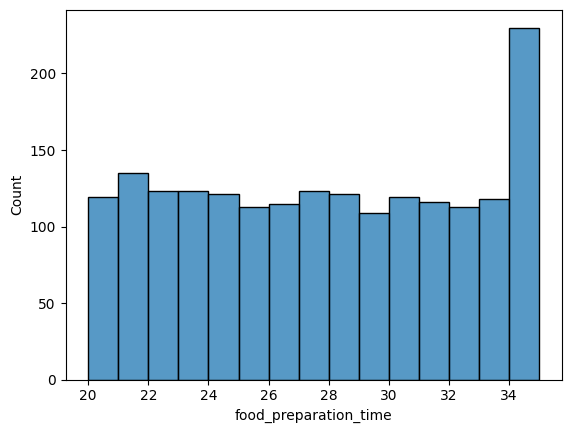

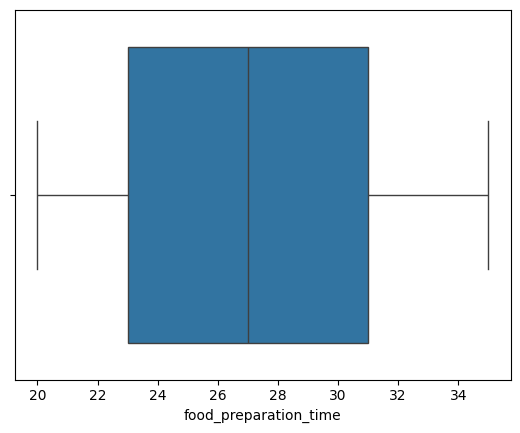

In [49]:
# Write the code here
sns.histplot(data=df,x='food_preparation_time', binwidth=1, stat="count")
plt.show()
sns.boxplot(data=df,x='food_preparation_time')
plt.show()

For column food_preparation_time:
We observe that the time from taking order timestamp and delivery pick is uniformly distributed at a count of approximately 120 counts between 20 and 34 minutes. However in the last bin for 35 minutes there was a count of over 200.

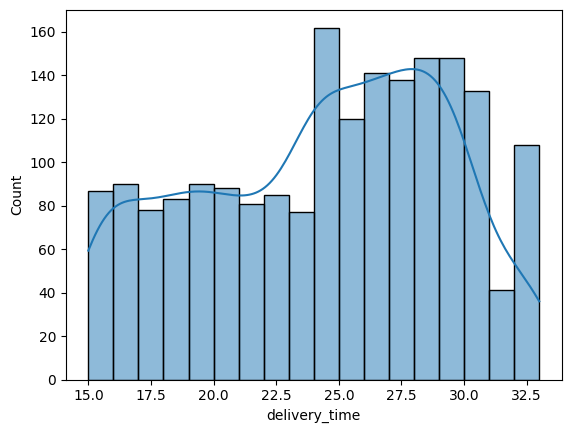

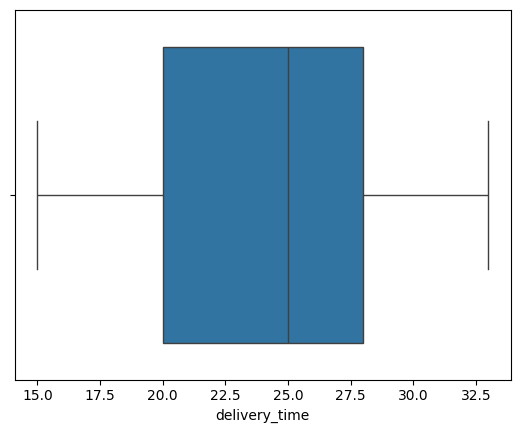

In [50]:
sns.histplot(data=df,x='delivery_time', binwidth = 1, kde=True, stat="count")
plt.show()
sns.boxplot(data=df,x='delivery_time')
plt.show()

For delivery_time column:
We see that the most occurrences of delivery time is bin 24-25 minutes. In the boxplot its observed that the data slightly skewed to the left.The delivery time between 24-31 minutes had an increased in counts to 120-160 times from approximately 90 counts.

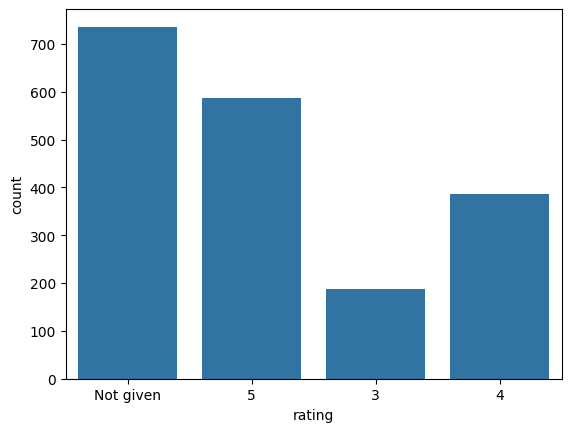

In [51]:
sns.countplot(data=df,x='rating')
plt.show()


For rating column:
Over 700 times the customer had not given a rating for the orders.

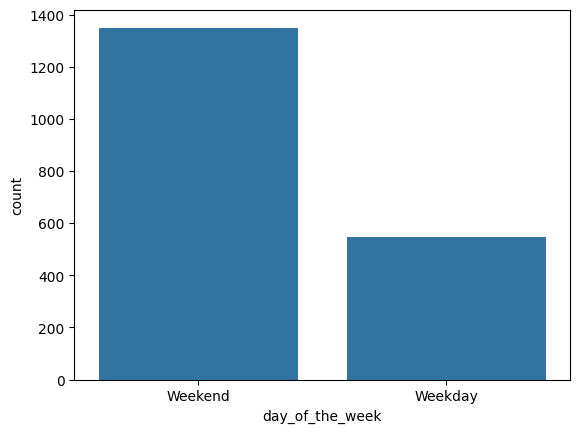

In [52]:
sns.countplot(data=df,x='day_of_the_week');
plt.show()


For day_of_the_week column:
There were more orders from customers on the weekend food at in New York.

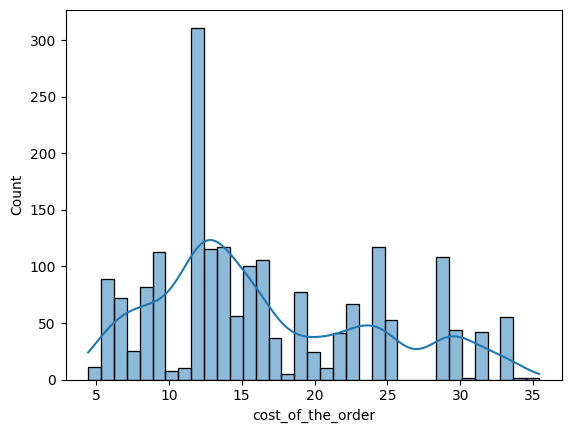

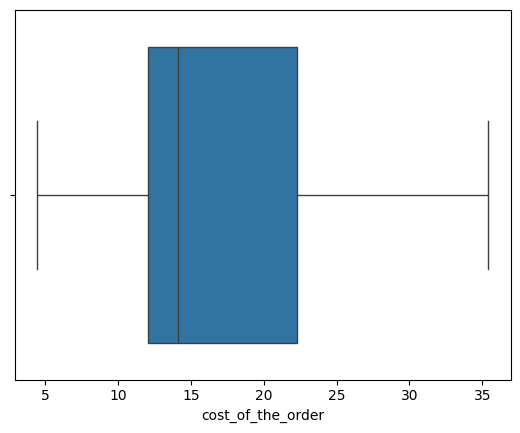

In [53]:
sns.histplot(data=df,x='cost_of_the_order',bins= 35, kde=True);
plt.show()
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

For column cost_of_the_order:
We observe that the cost per order is right skewed. This means that customers are preferring food at lower cost when orderding through the app.

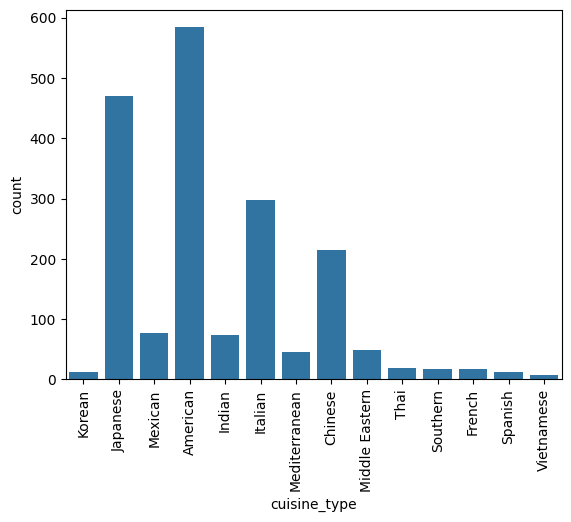

In [54]:

sns.countplot(data=df,x='cuisine_type')
plt.xticks(rotation=90);
plt.show()

For cuisine_type column:
We clearly see the 4 most popular foor cuisines are
Japanese, American, Italian and Chinese.

### : The Top 5 restaurants in terms of the number of orders received

In [55]:

df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


In [56]:
df['restaurant_name'].value_counts().nlargest(10) ##Find the value counts of 10 most restaurants.

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
RedFarm Broadway,59
RedFarm Hudson,55
TAO,49
Han Dynasty,46


#### Observations:
The top 5 restaurants in terms of number of orders are:
Shake Shack ,
The Meatball Shop ,
Blue Ribbon Sushi ,
Blue Ribbon Fried Chicken and
Parm

However in the data set in column restaurant_names Blue Ribbon (Ex. Sushi, Fried Chicken) could be names of dishes for the restaurant Blue Ribbon Sushi Bar & Grill.


### Relationship between cuisine type and day of the week.

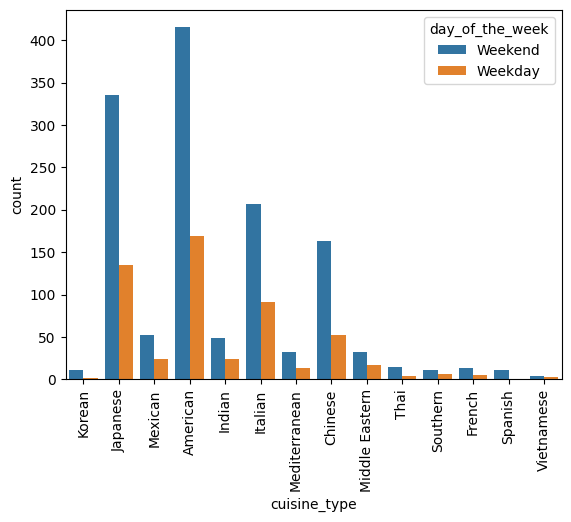

In [57]:
# Write the code here
sns.countplot(data=df,x='cuisine_type',hue = 'day_of_the_week')
plt.xticks(rotation=90);
plt.show()

In [58]:
df.groupby('day_of_the_week')['cuisine_type'].value_counts().nlargest(1) ##Find the largest count filtering day of the week by cuisine type.

,,count
day_of_the_week,cuisine_type,
Weekend,American,415


#### Observations:
On our histogram plot where we observe the cuisine with the most orders for the weekend is above 400 orders. Also once further investigating the dataset we could see that the American cuisine on the weekend is ordered 415 times.


###  Percentage of the orders that cost more than 20 dollars

In [59]:

df['cost_of_the_order'].ge(20).value_counts( normalize= True ) *100 ##Look at this column and count orders that are over 20 dollars and find percentage.


,proportion
cost_of_the_order,
False,70.758693
True,29.241307


#### Observations:
The percentage of orders that cost more than 20 dollars is 29.2%.


### Average order delivery time.

In [60]:

round( df['delivery_time'].mean(),2)

np.float64(24.16)

#### Observations:
The average delivery time for the delivery to arrive to customers once its been picked up is 24.162 minutes.



```
# This is formatted as code
```

### Top 3 customers with most frequesnt orders.

In [61]:

df['customer_id'].value_counts().nlargest(3) ##Find the 3 most repeat customers.

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:
The 3 customer id's that had the most frequent orders are id 52832:13 orders, 47440:10 orders, and 83287: 9 orders.


### Multivariate Analysis

###  Performing a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables)


In [62]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


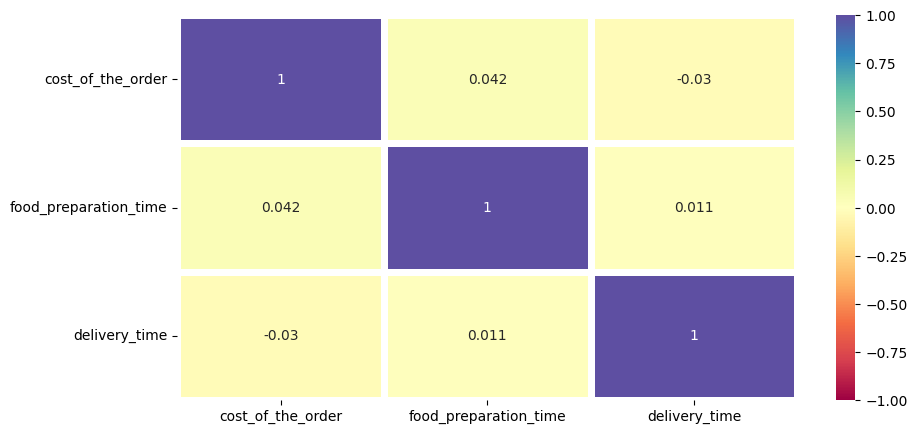

In [63]:
col_list = ['cost_of_the_order','food_preparation_time','delivery_time'] ##List the numerical variables.
plt.figure(figsize=(10,5))
sns.heatmap(df[col_list].corr(),annot=True,cmap='Spectral',vmin=-1,vmax=1,linewidths=5) ##Create heatmap and see the correlation between numerical variables.
plt.show()

For the three numerical variables cost_of_the_order, food_preparation_time and delivery_time there appears to be no correlation. This establishes that there is no relationship in these variables. Order and customer id are just identifiers so even though they are numerical we can ignore for the correlation map.

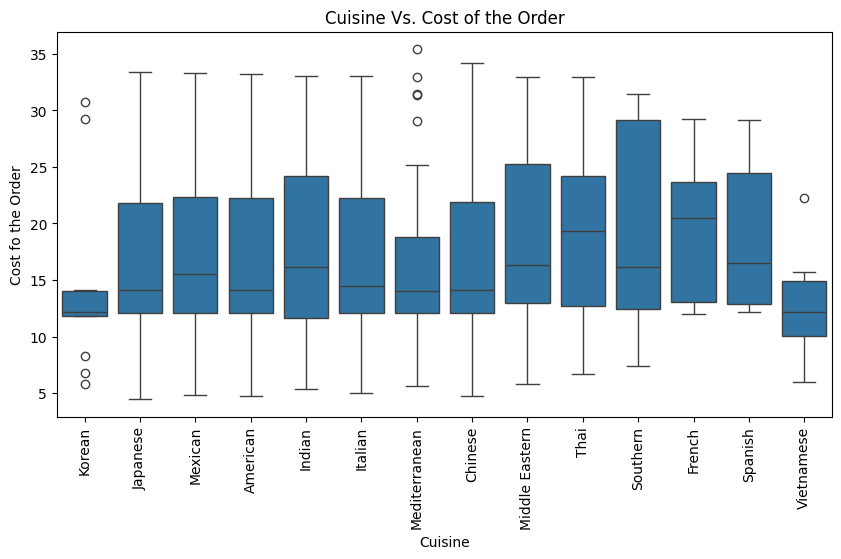

In [64]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,x='cuisine_type',y='cost_of_the_order')
plt.xticks(rotation=90);
plt.title('Cuisine Vs. Cost of the Order')
plt.xlabel('Cuisine')
plt.ylabel('Cost fo the Order')
plt.show()

We could see in these boxplots that most cuisines had a cost from about 10 to 25 dollars per order. Few outliers were observed but these could be normal since eating habits could differ.

/tmp/ipython-input-65-382983782.py:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df,x='day_of_the_week',y='food_preparation_time',ci=None)
/tmp/ipython-input-65-382983782.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df,x='day_of_the_week',y='delivery_time',ci=None, linestyle='dotted')


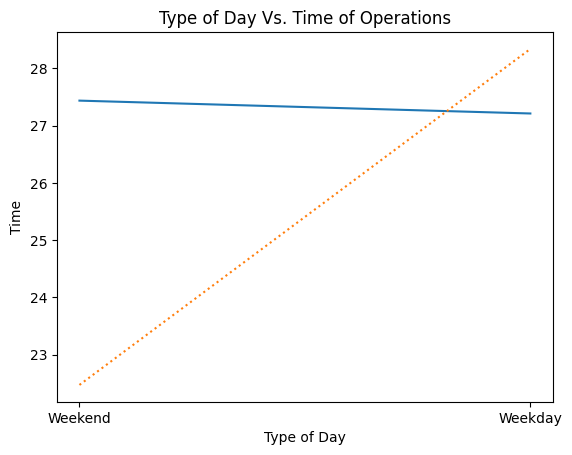

In [65]:

sns.lineplot(data=df,x='day_of_the_week',y='food_preparation_time',ci=None)

sns.lineplot(data=df,x='day_of_the_week',y='delivery_time',ci=None, linestyle='dotted')
plt.title('Type of Day Vs. Time of Operations') ##Labeling the title and x-y axis to clear up the table.
plt.xlabel('Type of Day')
plt.ylabel('Time')
plt.show();

On this chart we want to explore the relationship between type of day and time to prepare the order as well as the time to deliver. We clearly see order preparation is steadily the same (blue line). The time it takes to deliver the order on the weekend takes about 5 minutes less(dotted line).

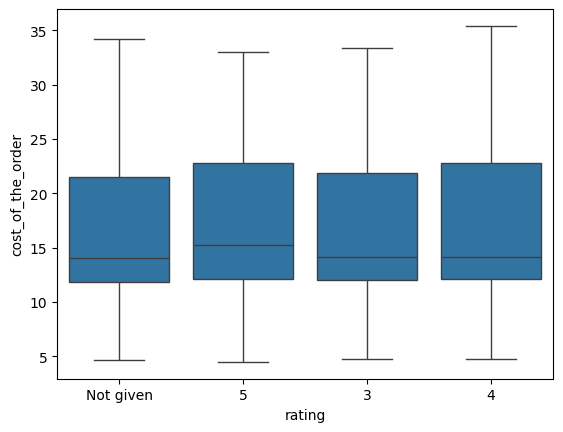

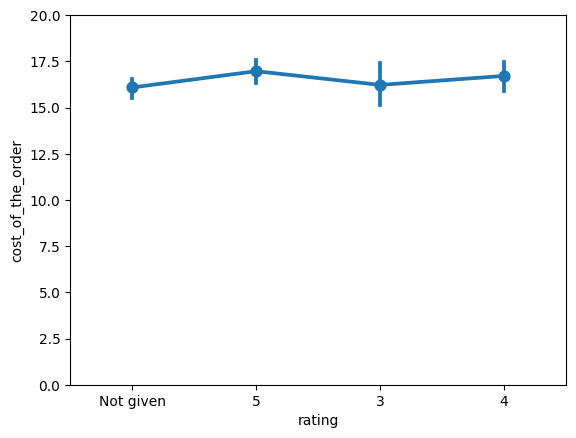

In [66]:
sns.boxplot(data=df, x='rating', y ='cost_of_the_order')
plt.yticks(rotation=0);
plt.show()
plt.figure()
sns.pointplot(data= df, x = 'rating', y = 'cost_of_the_order')
plt.ylim(0,20)
plt.show()

On these boxplots I am investigating if cost affected the ratings for the orders. We could see that the relationship of cost of the order and rating given is negligible. Upon closer look the ratings have central tendencies from 16.00 and 17.00 dollars.

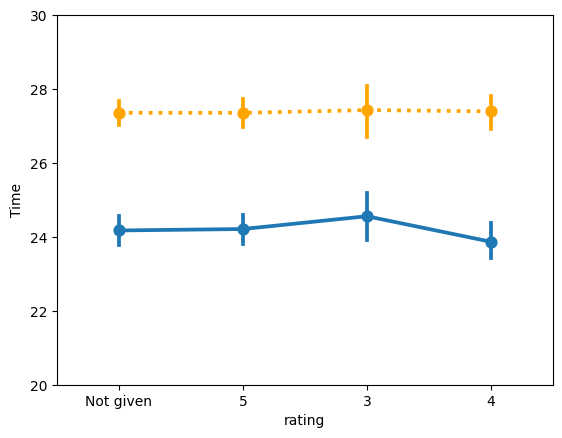

In [67]:
plt.figure()
sns.pointplot(data= df, x = 'rating', y = 'delivery_time')  ## Plotting points to see how time categories affected ratings.
sns.pointplot(data= df, x = 'rating', y = 'food_preparation_time', color = 'orange' ,linestyles= 'dotted')
plt.ylabel('Time')
plt.ylim(20,30)
plt.show()


Comparing rating and delivery time (blue line) there appears to be no relationship. This is also true for food preparation time (orange line).
This means time has no affect on customer ratings on orders.

### The top 10 restaurants on the basis of the type of ratings and their count.

In [68]:

df.groupby(['restaurant_name'])['rating'].value_counts().nlargest(10) ##Find the top 10 rating counts for the rating category.




restaurant_name            rating   
Shake Shack                Not given    86
                           5            60
The Meatball Shop          5            53
Shake Shack                4            50
The Meatball Shop          Not given    48
Blue Ribbon Sushi          Not given    46
Blue Ribbon Fried Chicken  5            32
                           Not given    32
Blue Ribbon Sushi          5            32
Parm                       Not given    29
Name: count, dtype: int64

In [69]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')## This line is to convert rating values to numeric and giving nan for the ratings that were not given.
rest_rating = df.groupby(['restaurant_name'])['rating'].agg(['mean','count'])##This is to create columns that give average ratings for each restaurant and count how many ratings were given.
rest_rating =  rest_rating[(rest_rating['mean'] > 4) & (rest_rating['count'] > 50)]## This is to filter out which results are above 4 rating and number of reviews above 50.
print(rest_rating)

                               mean  count
restaurant_name                           
Blue Ribbon Fried Chicken  4.328125     64
Blue Ribbon Sushi          4.219178     73
Shake Shack                4.278195    133
The Meatball Shop          4.511905     84


#### Observations:
The four restaurants that fit the criteria are Shake Shack, The Meatball Shop, Blue Ribbon Fried Chicken and Blue Ribbon Sushi. These were the only restaurants that had over 50 orders and average rating above 4.

###  If  the company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders.

In [70]:

over_20 = df[df['cost_of_the_order'] > 20] ##Create data frame with filtered cost of orders that are over 20 dollars
over_20_sum = over_20['cost_of_the_order'].sum() ## Sum the column cost of the order for all orders 20 dollars



over_5 = df[(df['cost_of_the_order'] >5) & (df['cost_of_the_order'] <= 20 )] ##Create data frame with filtered cost of orders between 5 to 20 dollars
over_5_sum = over_5['cost_of_the_order'].sum() ## Sum the column cost of the order for all orders of 5 to 20 dollars

total_revenue = over_20_sum * .25 + over_5_sum * .15 ##Arithmetic for the total revenue for the company
print(round(total_revenue,2))

6166.3


#### Observations:
The total revenue for the 1898 orders is $6166.30 .
As we see in the above code we used conditional operators to sum all the revenue.



```
# This is formatted as code
```

###  The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered).

In [71]:

df['total_time'] = df['delivery_time'] + df['food_preparation_time'] #created new column summing up delivery time and food prep
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,total_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,NaN,25,20,45
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,NaN,25,23,48
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5.0,23,28,51
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3.0,25,15,40
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4.0,25,24,49


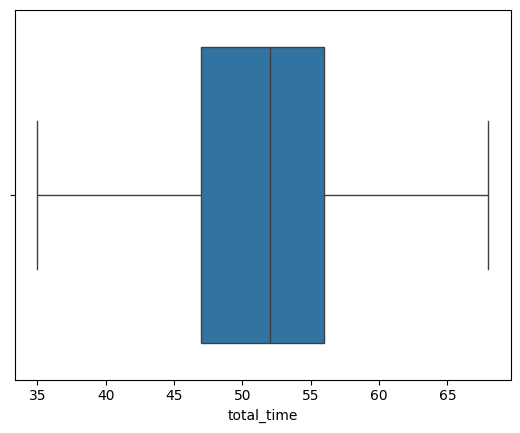

In [72]:

sns.boxplot(data=df,x='total_time')
plt.show()

In [73]:
over_60tt =  df[df['total_time'] > 60] ##Filter out the orders that are 60 minutes or more
count_60tt = over_60tt['total_time'].count().sum() ## Total count the number of orders
print(count_60tt)
perc_total =  round(count_60tt/df['order_id'].count(),3) ##Percentage of orders over 60 minutes
print(perc_total)

200
0.105


#### Observations:
The total amount of orders that are over 60 minutes (total_time) is 200 orders. This is about 10.5% of all orders. This could be estimated using the box plot for total time where 60 minute mark is intersects on the whisker. This means at least 75% of the orders took less than 60 minutes.

###  How does the mean delivery time vary during weekdays and weekends.

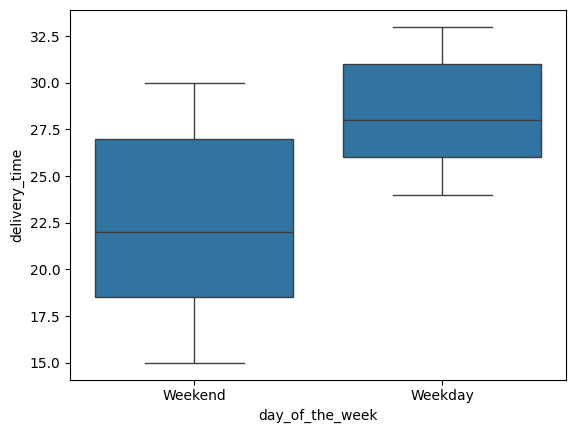

In [74]:

sns.boxplot(data=df,x='day_of_the_week',y='delivery_time')
plt.show()

(0.0, 30.0)

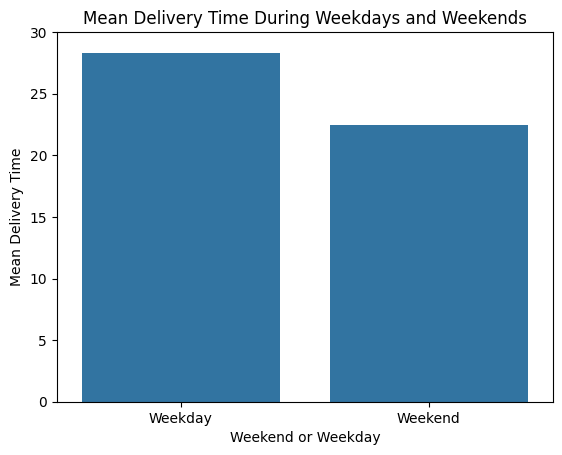

In [75]:
mean_delivery = df.groupby(['day_of_the_week'])['delivery_time'].mean()
sns.barplot(x=mean_delivery.index, y=mean_delivery.values)

plt.title('Mean Delivery Time During Weekdays and Weekends')
plt.xlabel('Weekend or Weekday')
plt.ylabel('Mean Delivery Time')
plt.ylim(0, 30)

In [76]:
print(mean_delivery)

day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64


#### Observations:

The average time that it took for orders to be delivered to customers after it was picked up is in the weekday 28 minutes about 6 minutes increase compared to weekend deliveries.


### Conclusions:
For this project we analyzed a dataset of 1898 food orders for the app FoodHub. The main focus is to see the relationship that feedback ratings had with other variables in the data set. Historically apps rely in ratings for the purpose of recomending restaurants to drive business. Also there are variables in this dataset that could help identify factors that affect efficiency of order deliveries. Here are some insights:

*   From the 12 types of cuisine types the 4 most popular cuisine types are Japanese, American, Italian and Chinese with 200+ orders.

*   Delivery time of orders on average are 6 minutes longer during the week day (28 minutes) compared to the weekend (22 minutes).


*   Feedback ratings are unaffected by increased cost of the orders.
*   Feedback ratings are unaffected by increased delivery time.


*   Increased demand for orders occur during the weekend.
*   10% of all orders take over 60 minutes to arrive at customers location.










### Recommendations:

*  Further investigate factors that increase delivery times on the weekdays.


*   Add further restaurants from the top four popular cuisines types.
*   Incentivize promotions for customers to order over $20.00 to increase the revenue.


*   More data should be procured so we have a deeper understanding on ratings and its relationship to times, cuisines and cost.





---